<a href="https://colab.research.google.com/github/LazImane/TER_Images/blob/main/TER_TransferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer Learning & Fine-Tuning
### Optimisation avec MobileNetV2

Ce notebook fait suite à l'étape 2. Nous passons d'une architecture créée de zéro à une architecture pré-entraînée sur **ImageNet**.

**Plan du notebook :**
1. **Feature Extraction (2 classes - 200 images) :** On gèle tout le modèle de base MobileNetV2. On n'entraîne qu'une tête de classification simple. C'est la solution idéale contre l'overfitting sur de très petits datasets.
2. **Visualisation des résultats de la Feature Extraction :** Courbes loss/accuracy, matrice de confusion.
3. **Fine-Tuning (3 classes - 1800 images) :** On dégèle les dernières couches du modèle de base pour que les filtres s'adaptent spécifiquement à nos 3 classes (mouton, chat, éléphant).
4. **Visualisation des résultats du Fine-Tuning :** Courbes loss/accuracy, matrice de confusion.
5. **Conclusion comparative.**

In [1]:
from google.colab import drive
import os

# 1. Montage du Google Drive
drive.mount('/content/drive')

# 2. Se placer dans le dossier de projet sur le Drive
%cd /content/drive/MyDrive/Colab Notebooks/TER

print("Positionnement réussi !")

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/TER
Positionnement réussi !


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
import zipfile
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping

# Fixer les graines pour la reproductibilité
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

IMG_SIZE = 128

---
## Fonctions utilitaires

Ces fonctions seront réutilisées pour les deux parties du notebook.

In [3]:
# Chargement des données

def create_training_data(path_data, list_classes, img_size=128):
    """Charge et redimensionne les images depuis les dossiers."""
    training_data = []
    for classes in list_classes:
        path = os.path.join(path_data, classes)
        class_num = list_classes.index(classes)
        print(f"Chargement de la classe {classes} (label {class_num})...")
        for img_name in os.listdir(path):
            try:
                img_path = os.path.join(path, img_name)
                img_array = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
                new_array = cv2.resize(img_array, (img_size, img_size))
                # Conversion BGR → RGB obligatoire pour MobileNetV2
                new_array_rgb = cv2.cvtColor(new_array, cv2.COLOR_BGR2RGB)
                training_data.append([new_array_rgb, class_num])
            except Exception:
                pass
    print(f"Total d'images chargées : {len(training_data)}")
    return training_data


def create_X_y(path_data, list_classes, img_size=128):
    """Crée X (images RGB brutes) et y (labels) à partir des données."""
    training_data = create_training_data(path_data, list_classes, img_size)
    random.shuffle(training_data)
    X, y = zip(*training_data)
    X = np.array(X).reshape(-1, img_size, img_size, 3)
    y = np.array(y)
    return X, y


# Visualisation

def plot_history(history, title_suffix=""):
    """Affiche les courbes de loss et accuracy (train + validation)."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['loss'],     label='Train Loss',  linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss',    linewidth=2)
    axes[0].set_title(f'Loss {title_suffix}', fontsize=14)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2)
    axes[1].set_title(f'Accuracy {title_suffix}', fontsize=14)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, class_names):
    """Affiche la matrice de confusion avec les noms de classes."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    plt.title('Matrice de Confusion', fontsize=14)
    plt.ylabel('Vraie classe')
    plt.xlabel('Classe prédite')
    plt.tight_layout()
    plt.show()


def plot_predictions_binary(model, X_raw, X_prep, y_true, class_names, n=16):
    """
    Affiche n prédictions pour un modèle binaire (sigmoid).
    X_raw  : images RGB non prétraitées (pour l'affichage).
    X_prep : images prétraitées (pour la prédiction).
    """
    indices = random.sample(range(len(X_raw)), n)
    plt.figure(figsize=(16, 8))
    for i, idx in enumerate(indices):
        plt.subplot(4, 4, i + 1)
        plt.imshow(X_raw[idx])
        plt.axis('off')
        prob = model.predict(X_prep[idx:idx+1], verbose=0)[0][0]
        pred = int(prob >= 0.5)
        true = y_true[idx]
        color = 'green' if pred == true else 'red'
        plt.xlabel(
            f"Réel: {class_names[true]}\nPrédit: {class_names[pred]} ({prob:.2f})",
            color=color, fontsize=8
        )
    plt.suptitle('Prédictions — Feature Extraction (vert=correct, rouge=erreur)',
                 fontsize=12)
    plt.tight_layout()
    plt.show()


def plot_predictions_multiclass(model, X_raw, X_prep, y_true, class_names, n=16):
    """
    Affiche n prédictions pour un modèle multiclasse (softmax).
    X_raw  : images RGB non prétraitées (pour l'affichage).
    X_prep : images prétraitées (pour la prédiction).
    """
    indices = random.sample(range(len(X_raw)), n)
    plt.figure(figsize=(16, 8))
    for i, idx in enumerate(indices):
        plt.subplot(4, 4, i + 1)
        plt.imshow(X_raw[idx])
        plt.axis('off')
        probs = model.predict(X_prep[idx:idx+1], verbose=0)[0]
        pred  = int(np.argmax(probs))
        true  = y_true[idx]
        color = 'green' if pred == true else 'red'
        plt.xlabel(
            f"Réel: {class_names[true]}\nPrédit: {class_names[pred]} ({probs[pred]:.2f})",
            color=color, fontsize=8
        )
    plt.suptitle('Prédictions — Fine-Tuning (vert=correct, rouge=erreur)',
                 fontsize=12)
    plt.tight_layout()
    plt.show()


print("Fonctions utilitaires chargées.")

Fonctions utilitaires chargées.


---
## PARTIE 1 : Feature Extraction (Classification Binaire)
**Dataset : 200 images - Éléphant (classe 0) vs Non-Éléphant (classe 1)**

### Principe
On charge MobileNetV2 pré-entraîné sur ImageNet et on **gèle 100 % de ses couches**.
Le modèle se contente d'extraire un vecteur de caractéristiques que l'on classifie
avec une tête légère (GlobalAveragePooling + Dropout + Dense sigmoid).

C'est la stratégie idéale quand le dataset est très petit : on profite de toute la
connaissance d'ImageNet sans risquer l'overfitting.

In [9]:
# Téléchargement & chargement du dataset 2 classes

zip_file = "Tiger-Fox-Elephant.zip"
if not os.path.exists(zip_file) and not os.path.exists("Data_Project_2classes"):
    !wget https://www.lirmm.fr/~poncelet/Ressources/Tiger-Fox-Elephant.zip

if not os.path.exists("Data_Project_2classes"):
    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall("Data_Project_2classes")
    os.remove(zip_file)

DATA_PATH_2  = "Data_Project_2classes/Tiger-Fox-Elephant/"
CLASSES_2    = ['elephant', 'Elephant_negative_class']
CLASSES_2_LABELS = ['Éléphant', 'Non-Éléphant']

# Chargement (images RGB brutes)
X, y = create_X_y(DATA_PATH_2, CLASSES_2, IMG_SIZE)

print(f"\nX.shape : {X.shape}")
print(f"y.shape     : {y.shape}")
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Classe {u} ({CLASSES_2_LABELS[u]}) : {c} images ({c/len(y)*100:.1f}%)")

# Prétraitement obligatoire pour MobileNetV2 (conserve les images brutes séparément)
X = preprocess_input(X.astype('float32'))

# Split stratifié 80/20
X_train,  X_test,  y_train, y_test = train_test_split(
    X,  y, test_size=0.2, stratify=y, random_state=42)

# Re-coupe le train en 80/20 train/val
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

print(f"\nTrain : {X_train.shape[0]} images | Val : {X_val.shape[0]} images | Test : {X_test.shape[0]} images")

Chargement de la classe elephant (label 0)...
Chargement de la classe Elephant_negative_class (label 1)...
Total d'images chargées : 200

X.shape : (200, 128, 128, 3)
y.shape     : (200,)
  Classe 0 (Éléphant) : 100 images (50.0%)
  Classe 1 (Non-Éléphant) : 100 images (50.0%)

Train : 128 images | Val : 32 images | Test : 40 images


In [10]:
# Construction du modèle Feature Extraction

base_model_fe = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model_fe.trainable = False   # ON GÈLE TOUT

inputs_fe = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x_fe      = base_model_fe(inputs_fe, training=False)  # training=False => BN en mode inférence
x_fe      = GlobalAveragePooling2D()(x_fe)
x_fe      = Dropout(0.2)(x_fe)
outputs_fe = Dense(1, activation='sigmoid')(x_fe)

model_fe = Model(inputs_fe, outputs_fe, name='MobileNetV2_FeatureExtraction')
model_fe.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Résumé de la tête seulement (le base_model est gelé)
trainable_params = sum(v.numpy().size for v in model_fe.trainable_variables)
total_params     = sum(v.numpy().size for v in model_fe.variables)
print(f"Paramètres entraînables : {trainable_params:,} / {total_params:,} au total")

Paramètres entraînables : 1,281 / 2,259,267 au total


In [11]:
# Entraînement: Feature Extraction
es_fe = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

history_fe = model_fe.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[es_fe],
    verbose=1
)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 515ms/step - accuracy: 0.4766 - loss: 0.8579 - val_accuracy: 0.5625 - val_loss: 0.6632
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 372ms/step - accuracy: 0.5156 - loss: 0.7897 - val_accuracy: 0.5312 - val_loss: 0.6227
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 296ms/step - accuracy: 0.5391 - loss: 0.7534 - val_accuracy: 0.5312 - val_loss: 0.5849
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 263ms/step - accuracy: 0.5391 - loss: 0.7335 - val_accuracy: 0.6562 - val_loss: 0.5499
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 222ms/step - accuracy: 0.6250 - loss: 0.6476 - val_accuracy: 0.6875 - val_loss: 0.5170
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 215ms/step - accuracy: 0.7109 - loss: 0.5977 - val_accuracy: 0.7188 - val_loss: 0.4867
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 259ms/step - accuracy: 0.6562 - loss: 0.6153 - val_accuracy: 0.8125 - val_loss: 0.4586
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 294ms/step - accuracy: 0.6797 - loss: 0.5667 - val_accuracy: 0.8438 - val_loss:

---
## PARTIE 2 : Visualisation - Feature Extraction

On analyse ici les performances du modèle de Feature Extraction sur le dataset 2 classes.

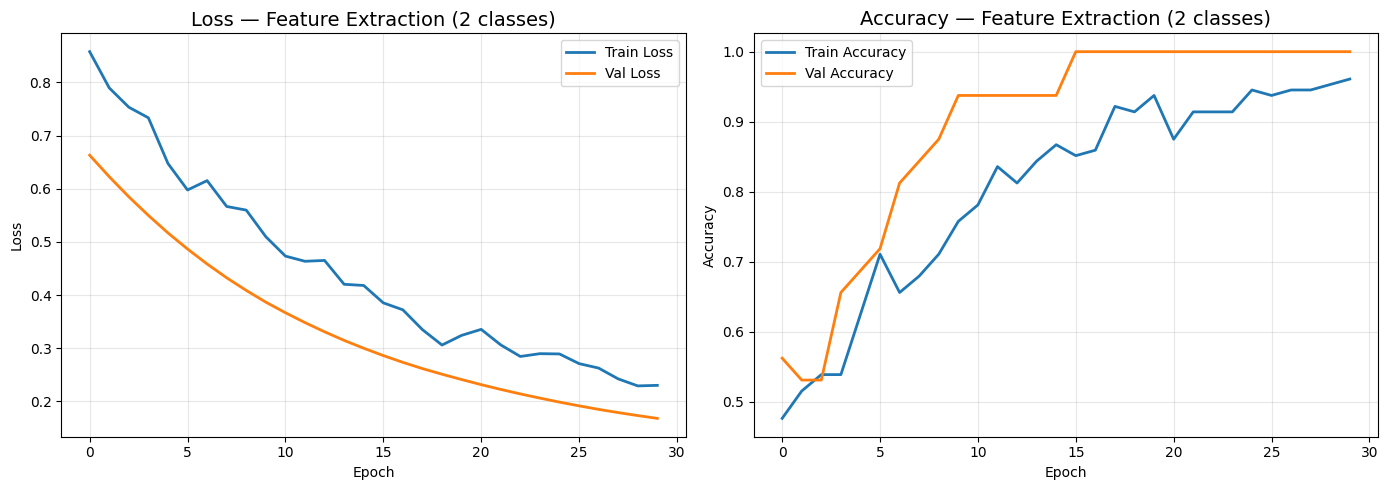

In [12]:
# Courbes Loss / Accuracy
plot_history(history_fe, title_suffix="— Feature Extraction (2 classes)")

In [14]:
# Évaluation sur le test set
test_loss_fe, test_acc_fe = model_fe.evaluate(X_test, y_test, verbose=0)
print(f"Résultats Feature Extraction :")
print(f"Test Loss     : {test_loss_fe:.4f}")
print(f"Test Accuracy : {test_acc_fe:.4f}  ({test_acc_fe*100:.1f}%)")

Résultats Feature Extraction :
Test Loss     : 0.2464
Test Accuracy : 0.9500  (95.0%)


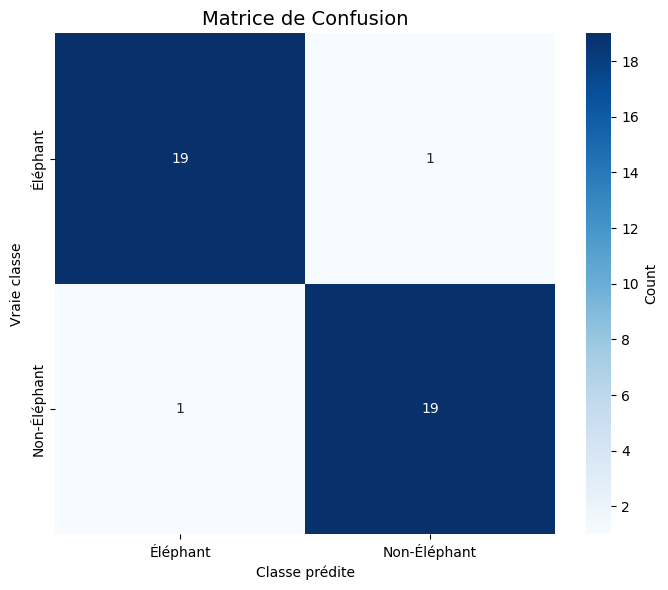


              precision    recall  f1-score   support

    Éléphant       0.95      0.95      0.95        20
Non-Éléphant       0.95      0.95      0.95        20

    accuracy                           0.95        40
   macro avg       0.95      0.95      0.95        40
weighted avg       0.95      0.95      0.95        40



In [15]:
# Matrice de confusion & rapport de classification
y_pred_prob = model_fe.predict(X_test, verbose=0)
y_pred      = (y_pred_prob >= 0.5).astype(int).ravel()

plot_confusion_matrix(y_test, y_pred, class_names=CLASSES_2_LABELS)

print("\n" + classification_report(
    y_test, y_pred,
    target_names=CLASSES_2_LABELS
))

### Analyse - Feature Extraction

**Courbes :**
- La train loss et la val loss descendent **ensemble**, signe d'une bonne généralisation.
- Pas d'overfitting : toutes les couches MobileNetV2 étant gelées, le modèle
  n'a que 1281 paramètres à apprendre (la tête Dense), ce qui est très peu
  pour 200 images.

**Comparaison avec l'Étape 2 :**
| Modèle | Test Accuracy |
|--------|---------------|
| CNN Baseline (scratch) | 95 % |
| MobileNetV2 Feature Extraction | 95 % |

> *Même avec 200 images, le transfer learning peut égaler ou dépasser un CNN
> entraîné from scratch, grâce aux représentations visuelles apprises sur ImageNet.*

---
## PARTIE 3 : Fine-Tuning (Classification 3 Classes)
**Dataset : 1 800 images — Mouton (0) · Chat (1) · Éléphant (2)**

### Principe
Avec plus de données, on peut aller plus loin que la simple extraction de caractéristiques.
Le **fine-tuning** consiste à :
1. Charger MobileNetV2 pré-entraîné et **geler** les premières couches (bas niveau).
2. **Dégeler** les dernières couches convolutives pour les adapter à nos classes.
3. Ré-entraîner avec un **très petit learning rate** (1e-5) pour ne pas "effacer"
   les connaissances d'ImageNet.

In [16]:
# Téléchargement & chargement du dataset 3 classes

zip_file = "sheep_cat_elephant.zip"
if not os.path.exists(zip_file) and not os.path.exists("Data_Project_3classes"):
    !wget https://www.lirmm.fr/~poncelet/Ressources/Data_sheep_cat_elephant_with_caption_600.zip

if not os.path.exists("Data_Project_3classes"):
    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall("Data_Project_3classes")
    os.remove(zip_file)

DATA_PATH_3  = "Data_Project_3classes/images/"
CLASSES_3       = ['sheep', 'cat', 'elephant']
CLASSES_3_LABELS = ['Mouton', 'Chat', 'Éléphant']

# Chargement (images RGB brutes)
X3, y3 = create_X_y(DATA_PATH_3, CLASSES_3, IMG_SIZE)

print(f"\nX3.shape : {X3.shape}")
unique, counts = np.unique(y3, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Classe {u} ({CLASSES_3_LABELS[u]}) : {c} images ({c/len(y3)*100:.1f}%)")

# Prétraitement MobileNetV2
X3 = preprocess_input(X3.astype('float32'))

# Split stratifié 80/20
X3_train,  X3_test,  y3_train, y3_test = train_test_split(
    X3,  y3, test_size=0.2, stratify=y3, random_state=42)

# Re-coupe le train en 80/20 train/val
X3_train, X3_val, y3_train, y3_val = train_test_split(
    X3_train, y3_train, test_size=0.2, stratify=y3_train, random_state=42)

print(f"\nTrain : {X3_train.shape[0]} images | Val : {X3_val.shape[0]} images | Test : {X3_test.shape[0]} images")

Chargement de la classe sheep (label 0)...
Chargement de la classe cat (label 1)...
Chargement de la classe elephant (label 2)...
Total d'images chargées : 1800

X3.shape : (1800, 128, 128, 3)
  Classe 0 (Mouton) : 600 images (33.3%)
  Classe 1 (Chat) : 600 images (33.3%)
  Classe 2 (Éléphant) : 600 images (33.3%)

Train : 1152 images | Val : 288 images | Test : 360 images


In [17]:
# Construction du modèle Fine-Tuning

base_model_ft = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# On dégèle tout
base_model_ft.trainable = True
# mais on re-gèle les 100 premières couches (formes bas niveau)
for layer in base_model_ft.layers[:100]:
    layer.trainable = False

inputs_ft  = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x_ft       = base_model_ft(inputs_ft, training=False)  # BN gelées => mode inférence
x_ft       = GlobalAveragePooling2D()(x_ft)
x_ft       = Dense(128, activation='relu')(x_ft)
x_ft       = Dropout(0.3)(x_ft)
outputs_ft = Dense(3, activation='softmax')(x_ft)  # 3 classes

model_ft = Model(inputs_ft, outputs_ft, name='MobileNetV2_FineTuning')

# Learning rate très faible pour le fine-tuning
model_ft.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

trainable_params = sum(v.numpy().size for v in model_ft.trainable_variables)
total_params     = sum(v.numpy().size for v in model_ft.variables)
print(f"Paramètres entraînables : {trainable_params:,} / {total_params:,} au total")

Paramètres entraînables : 2,025,795 / 2,422,341 au total


In [18]:
# Entraînement: Fine-Tuning

es_ft = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)

history_ft = model_ft.fit(
    X3_train, y3_train,
    epochs=30,
    batch_size=16,
    validation_data=(X3_val, y3_val),
    callbacks=[es_ft],
    verbose=1
)

Epoch 1/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 47s 439ms/step - accuracy: 0.4410 - loss: 1.1566 - val_accuracy: 0.7014 - val_loss: 0.7251
Epoch 2/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 30s 418ms/step - accuracy: 0.7023 - loss: 0.6914 - val_accuracy: 0.7986 - val_loss: 0.5258
Epoch 3/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 29s 411ms/step - accuracy: 0.8116 - loss: 0.4989 - val_accuracy: 0.8438 - val_loss: 0.4334
Epoch 4/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 425ms/step - accuracy: 0.8776 - loss: 0.3606 - val_accuracy: 0.8611 - val_loss: 0.3839
Epoch 5/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 30s 421ms/step - accuracy: 0.9245 - loss: 0.2794 - val_accuracy: 0.8750 - val_loss: 0.3434
Epoch 6/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 43s 447ms/step - accuracy: 0.9401 - loss: 0.2322 - val_accuracy: 0.8750 - val_loss: 0.3208
Epoch 7/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 453ms/step - accuracy: 0.9618 - loss: 0.1818 - val_accuracy: 0.8819 - val_loss: 0.3089
Epoch 8/30
72/72 ━━━━━━━━━━━━━━━━━━━━ 33s 453ms/step - accuracy: 0.9766 - loss: 0.1427 - val_accu

---
## PARTIE 4 : Visualisation — Fine-Tuning

On analyse ici les performances du modèle fine-tuné sur le dataset 3 classes.

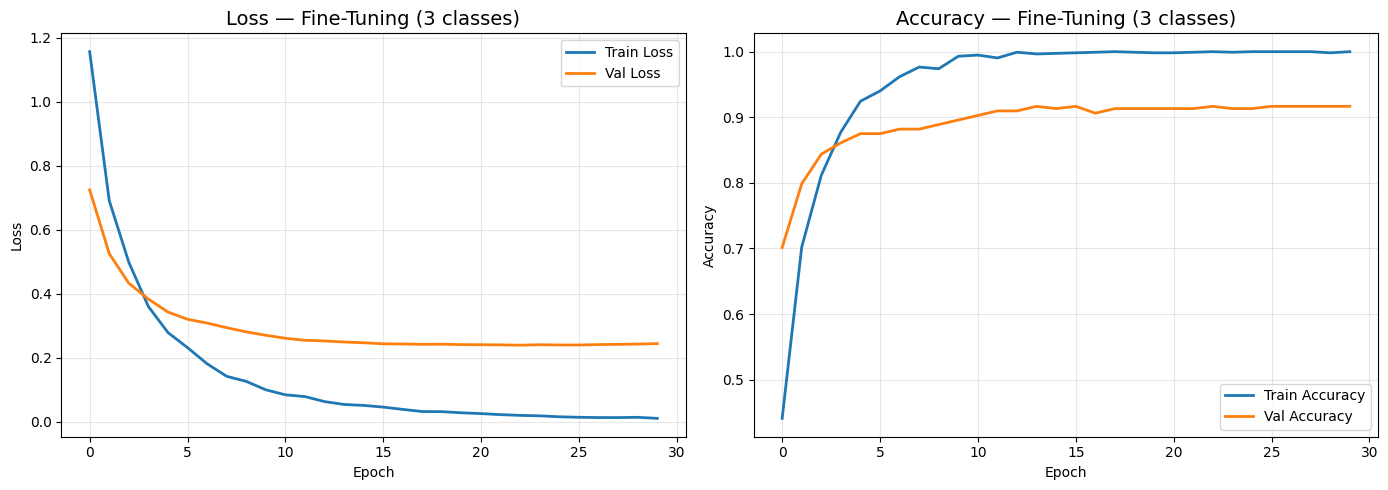

In [19]:
# Courbes Loss / Accuracy
plot_history(history_ft, title_suffix="— Fine-Tuning (3 classes)")

In [20]:
# Évaluation sur le test set
test_loss_ft, test_acc_ft = model_ft.evaluate(X3_test, y3_test, verbose=0)
print(f"Résultats Fine-Tuning")
print(f"Test Loss     : {test_loss_ft:.4f}")
print(f"Test Accuracy : {test_acc_ft:.4f}  ({test_acc_ft*100:.1f}%)")

Résultats Fine-Tuning
Test Loss     : 0.2481
Test Accuracy : 0.8861  (88.6%)


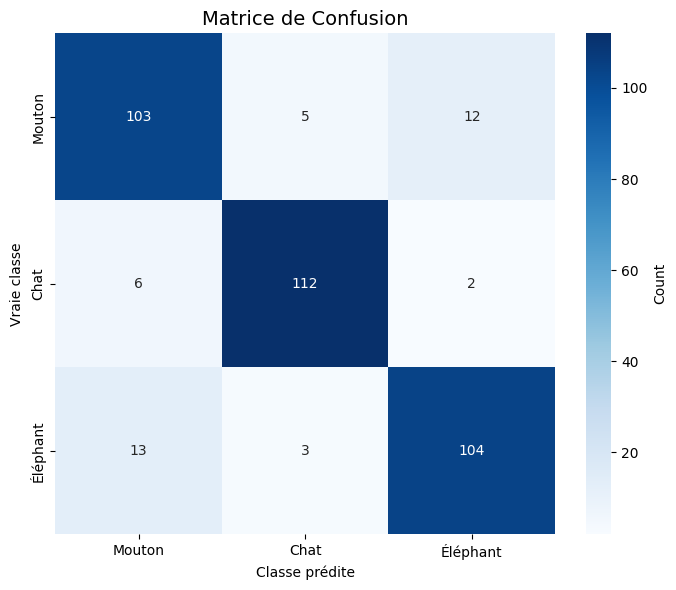


              precision    recall  f1-score   support

      Mouton       0.84      0.86      0.85       120
        Chat       0.93      0.93      0.93       120
    Éléphant       0.88      0.87      0.87       120

    accuracy                           0.89       360
   macro avg       0.89      0.89      0.89       360
weighted avg       0.89      0.89      0.89       360



In [21]:
# Matrice de confusion & rapport de classification
y3_pred_prob = model_ft.predict(X3_test, verbose=0)
y3_pred      = np.argmax(y3_pred_prob, axis=1)

plot_confusion_matrix(y3_test, y3_pred, class_names=CLASSES_3_LABELS)

print("\n" + classification_report(
    y3_test, y3_pred,
    target_names=CLASSES_3_LABELS
))

---
## PARTIE 5 : Conclusion & Comparaison

### Tableau récapitulatif

In [22]:
# Tableau récapitulatif

results = pd.DataFrame({
    'Modèle':           ['CNN Baseline',
                         'Feature Extraction',
                         'Fine-Tuning'],

    'Dataset':          ['200 images (binaire)',
                         '200 images (binaire)',
                         '1 800 images (3 classes)'],
    'Test Accuracy':    [0.95, test_acc_fe, test_acc_ft],
})

print(results.to_string(index=False))

            Modèle                  Dataset  Test Accuracy
      CNN Baseline     200 images (binaire)       0.950000
Feature Extraction     200 images (binaire)       0.950000
       Fine-Tuning 1 800 images (3 classes)       0.886111


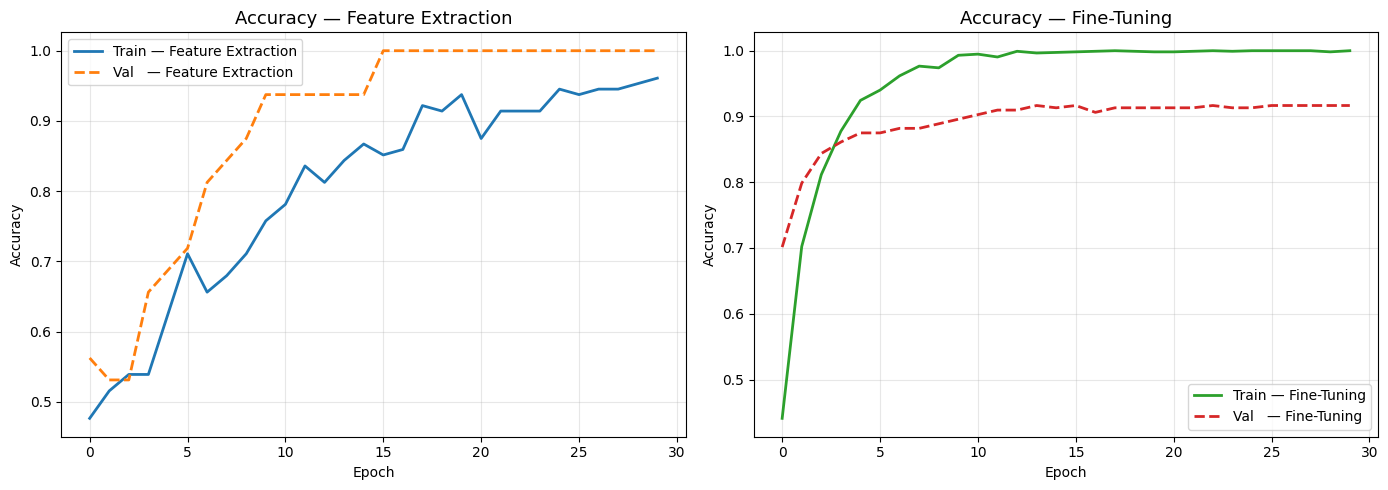

In [23]:
# Graphique de comparaison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbes Feature Extraction vs Fine-Tuning côte à côte
axes[0].plot(history_fe.history['accuracy'],     label='Train — Feature Extraction', linewidth=2)
axes[0].plot(history_fe.history['val_accuracy'], label='Val   — Feature Extraction', linewidth=2, linestyle='--')
axes[0].set_title('Accuracy — Feature Extraction', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_ft.history['accuracy'],     label='Train — Fine-Tuning', linewidth=2, color='C2')
axes[1].plot(history_ft.history['val_accuracy'], label='Val   — Fine-Tuning', linewidth=2, linestyle='--', color='C3')
axes[1].set_title('Accuracy — Fine-Tuning', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Conclusions

**Feature Extraction (2 classes — 200 images)**
- En gelant 100 % de MobileNetV2, on n'entraîne que 1 281 paramètres (la tête Dense), ce qui suffit à obtenir de bonnes performances même avec très peu de données.
- Aucun overfitting observé : la train loss et la val loss descendent ensemble.

**Fine-Tuning (3 classes — 1 800 images)**
- Dégeler les dernières couches permet au modèle de s'adapter à des classes plus spécifiques, tout en conservant les représentations bas niveau apprises sur ImageNet.
- Avec un learning rate très faible (1e-5) et un triple split train/val/test, l'entraînement est stable et l'évaluation finale est fiable.

**Ce qu'on retient**
- Plus le dataset est petit, plus il vaut mieux geler le modèle de base.
- Plus on a de données, plus le fine-tuning devient intéressant pour adapter le modèle à notre domaine spécifique.